# 01.1 — Rainfall Threshold & Occurrence Analysis

Khảo sát các ngưỡng mưa vết (trace rain) và phân tích tỷ lệ xuất hiện ngày có mưa theo thời gian.


In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reconfigure encoding
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# Path resolution
ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "src").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.data.loader import DataLoader, time_series_split
from src.eda.pipeline import compare_rain_thresholds

# 1. Nạp dữ liệu Train chuẩn hóa (Zero Leakage)
df = DataLoader().load_data()
train_df, _ = time_series_split(df)
print(f"📊 Tập Train phân tích: {len(train_df):,} ngày ({train_df['Ngày'].min().date()} → {train_df['Ngày'].max().date()})")

# 2. Bảng so sánh thực nghiệm các ngưỡng mưa ứng viên
candidate_thresholds = [0.0, 0.1, 0.6, 1.0]
threshold_comparison = compare_rain_thresholds(
    train_df,
    target_col='Lượng mưa',
    candidate_thresholds=candidate_thresholds
)

print("\n📋 BẢNG SO SÁNH PHÂN BỐ THỰC NGHIỆM THEO CÁC NGƯỠNG MƯA ỨNG VIÊN:")
print(threshold_comparison.to_string(index=False))


📊 Tập Train phân tích: 7,060 ngày (2001-01-01 → 2020-04-30)

📋 BẢNG SO SÁNH PHÂN BỐ THỰC NGHIỆM THEO CÁC NGƯỠNG MƯA ỨNG VIÊN:
 threshold_mm      condition  days_count  pct_of_total  incremental_gap_pct
          0.0 Exactly 0.0 mm        1917         27.15                 0.00
          0.1       < 0.1 mm        2742         38.84                11.69
          0.6       < 0.6 mm        3608         51.10                12.27
          1.0       < 1.0 mm        3974         56.29                 5.18


In [2]:
# 3. Phân tích chi tiết số liệu xuất hiện sự kiện mưa
target = train_df['Lượng mưa'].dropna()
total_days = len(target)

zero_days = int((target == 0.0).sum())
trace_days = int(((target > 0.0) & (target < 0.1)).sum())
dry_days = int((target < 0.1).sum())
rain_days = int((target >= 0.1).sum())

# Tính số đợt mưa (rainfall events) - chuỗi ngày mưa liên tiếp
rain_indicator = (target >= 0.1).astype(int)
event_starts = ((rain_indicator == 1) & (rain_indicator.shift(1, fill_value=0) == 0)).sum()

print("🌧️ THỐNG KÊ CHI TIẾT SỰ KIỆN MƯA (TẬP TRAIN):")
print(f"   • Tổng số ngày khảo sát:              {total_days:,} ngày")
print(f"   • Số ngày mưa chính xác 0.0 mm:       {zero_days:,} ngày ({zero_days/total_days*100:.2f}%)")
print(f"   • Số ngày mưa vết (0.0 < y < 0.1 mm): {trace_days:,} ngày ({trace_days/total_days*100:.2f}%)")
print(f"   • Số ngày không mưa theo WMO (<0.1):  {dry_days:,} ngày ({dry_days/total_days*100:.2f}%)")
print(f"   • Số ngày có mưa đo lường (>= 0.1 mm): {rain_days:,} ngày ({rain_days/total_days*100:.2f}%)")
print(f"   • Số đợt mưa riêng biệt (rain events):{event_starts:,} đợt")


🌧️ THỐNG KÊ CHI TIẾT SỰ KIỆN MƯA (TẬP TRAIN):
   • Tổng số ngày khảo sát:              7,060 ngày
   • Số ngày mưa chính xác 0.0 mm:       1,917 ngày (27.15%)
   • Số ngày mưa vết (0.0 < y < 0.1 mm): 825 ngày (11.69%)
   • Số ngày không mưa theo WMO (<0.1):  2,742 ngày (38.84%)
   • Số ngày có mưa đo lường (>= 0.1 mm): 4,318 ngày (61.16%)
   • Số đợt mưa riêng biệt (rain events):511 đợt


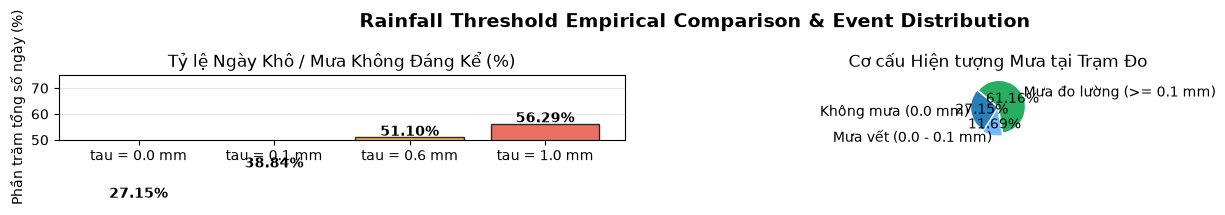

In [3]:
# 4. Trực quan hóa So sánh Ngưỡng Mưa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rainfall Threshold Empirical Comparison & Event Distribution', fontsize=14, fontweight='bold')

# Bar plot: Cumulative dry fraction across candidate thresholds
thresholds_str = [f"tau = {t} mm" for t in threshold_comparison['threshold_mm']]
ax1.bar(thresholds_str, threshold_comparison['pct_of_total'], color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8, edgecolor='black')
ax1.set_title('Tỷ lệ Ngày Khô / Mưa Không Đáng Kể (%)')
ax1.set_ylabel('Phần trăm tổng số ngày (%)')
ax1.set_ylim(50, 75)
ax1.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(threshold_comparison['pct_of_total']):
    ax1.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold')

# Donut chart: Zero vs Trace vs Measurable Rain
labels = ['Không mưa (0.0 mm)', 'Mưa vết (0.0 - 0.1 mm)', 'Mưa đo lường (>= 0.1 mm)']
sizes = [zero_days, trace_days, rain_days]
colors = ['#2980b9', '#74b9ff', '#27ae60']
ax2.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=140, colors=colors, explode=(0.03, 0.08, 0.05))
ax2.set_title('Cơ cấu Hiện tượng Mưa tại Trạm Đo')

plt.tight_layout()
plt.show()


In [4]:
# 5. Quyết định Ngưỡng Vận hành và Xuất Artifact
CHOSEN_THRESHOLD = 0.1

threshold_artifact = {
    "chosen_threshold_mm": CHOSEN_THRESHOLD,
    "rationale": "WMO standard trace rain (0.1 mm) — excludes dew/condensation and sensor noise below rain gauge tip sensitivity.",
    "total_train_days": total_days,
    "zero_days_count": zero_days,
    "zero_days_pct": round(zero_days / total_days * 100, 2),
    "trace_days_count": trace_days,
    "trace_days_pct": round(trace_days / total_days * 100, 2),
    "dry_days_count": dry_days,
    "dry_days_pct": round(dry_days / total_days * 100, 2),
    "rain_days_count": rain_days,
    "rain_days_pct": round(rain_days / total_days * 100, 2),
    "rainfall_events_count": int(event_starts),
    "candidate_thresholds_evaluated": threshold_comparison.to_dict(orient='records')
}

OUTPUT_DIR = ROOT_DIR / "notebooks" / "eda" / "outputs"
DATA_OUTPUT_DIR = ROOT_DIR / "data" / "processed" / "eda_outputs"

artifact_path = OUTPUT_DIR / "threshold_report.json"
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(threshold_artifact, f, indent=2, ensure_ascii=False)

with open(DATA_OUTPUT_DIR / "threshold_report.json", "w", encoding="utf-8") as f:
    json.dump(threshold_artifact, f, indent=2, ensure_ascii=False)

print(f"💾 Threshold report exported to: {artifact_path}")
print(f"   • Quyết định ngưỡng vận hành: tau = {CHOSEN_THRESHOLD} mm")
print(f"   • Tỷ lệ ngày khô: {threshold_artifact['dry_days_pct']}% | Ngày mưa: {threshold_artifact['rain_days_pct']}%")


💾 Threshold report exported to: D:\DS108_project\notebooks\eda\outputs\threshold_report.json
   • Quyết định ngưỡng vận hành: tau = 0.1 mm
   • Tỷ lệ ngày khô: 38.84% | Ngày mưa: 61.16%
